# Paired CycleGAN test and WSI inference

`Unstain2HnE_CycleGAN_train.ipynb`에서 생성한 best checkpoint를 동일한 전처리로 검사합니다. Held-out paired patch 평가와 2.0 MPP WSI 변환을 모두 실행합니다.

In [1]:
from pathlib import Path
import random

import matplotlib.pyplot as plt
import numpy as np
import openslide
import torch
from PIL import Image
from torchvision.transforms import functional as TF

from cyclegan_core import collect_domain_paths, simple_ssim, split_domains_by_slide
from cyclegan_inference import infer_cyclegan_patch, load_cyclegan_models
from two_stage_inference import infer_wsi
from two_stage_virtual_staining import prepare_physical_view

torch.set_grad_enabled(False)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

/home/user/anaconda3/envs/urban/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device(type='cuda')

In [2]:
DATA_DIR = Path('../../data/HnE_n_UNStaining/patch_dataset_mpp05_2048')
CHECKPOINT = Path('../../model/Unstain2HnE_paired_cyclegan_mpp20_v1/best.pt')
WSI_INPUT = Path('../../data/HnE_n_UNStaining/Un-Stained-tiff/WC21-01958(A1-1).tiff')
OUTPUT_DIR = Path('../../results/Unstain2HnE_paired_cyclegan_mpp20_v1/wsi_test')
WSI_OUTPUT = OUTPUT_DIR / f'{WSI_INPUT.stem}_CycleGAN_virtual_HnE_2mpp.tiff'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

wsi_generator, identity_colorizer, generator_ba, metadata = load_cyclegan_models(
    CHECKPOINT, device
)
metadata

{'device': 'cuda',
 'epoch': 29,
 'unstain_od_max': 0.5239836573600769,
 'input_size': 512,
 'original_size': 2048,
 'source_mpp': 0.5,
 'target_mpp': 2.0,
 'paired_training': True}

## 1. Held-out paired patch test

학습 노트북과 같은 slide-wise split을 재현합니다. `Recovered Unstain OD`는 cycle consistency 확인용이며 최종 H&E 품질 지표는 아닙니다.

In [3]:
unstain_paths, hne_paths = collect_domain_paths(DATA_DIR, 'png')
_, _, val_unstain, val_hne = split_domains_by_slide(
    unstain_paths, hne_paths, val_fraction=0.1, seed=42
)
val_hne_by_name = {path.name: path for path in val_hne}
validation_pairs = [(path, val_hne_by_name[path.name]) for path in val_unstain if path.name in val_hne_by_name]
# two-stage test notebook과 동일한 네 patch를 사용해 직접 비교합니다.
comparison_names = [
    'WC21-01356(B1-1)_00022_x13104_y6552.png',
    'WC21-01351(A1-2)_00022_x14742_y3276.png',
    'MD22-4228(A1-3)_00009_x11466_y1638.png',
    'WC21-01958(A1-1)_00012_x11466_y9828.png',
]
validation_by_name = {unstain.name: (unstain, hne) for unstain, hne in validation_pairs}
selected_pairs = [validation_by_name[name] for name in comparison_names]

patch_results = []
physical_params = {
    'input_size': metadata['input_size'], 'original_size': metadata['original_size'],
    'source_mpp': metadata['source_mpp'], 'target_mpp': metadata['target_mpp'],
}
for unstain_path, hne_path in selected_pairs:
    unstain_rgb = Image.open(unstain_path).convert('RGB')
    real_hne = prepare_physical_view(Image.open(hne_path).convert('RGB'), physical_params)
    unstain_od, recovered_od, generated_rgb = infer_cyclegan_patch(
        unstain_rgb, wsi_generator, generator_ba, metadata
    )
    generated_tensor = TF.to_tensor(generated_rgb) * 2 - 1
    real_tensor = TF.to_tensor(real_hne) * 2 - 1
    score = float(simple_ssim(generated_tensor[None].to(device), real_tensor[None].to(device)))
    patch_results.append((unstain_path.name, unstain_rgb, unstain_od, generated_rgb, real_hne, recovered_od, score))

print('Held-out pairs:', len(validation_pairs))
print('Mean paired SSIM:', np.mean([row[-1] for row in patch_results]))

Held-out pairs: 148
Mean paired SSIM: 0.3524722531437874


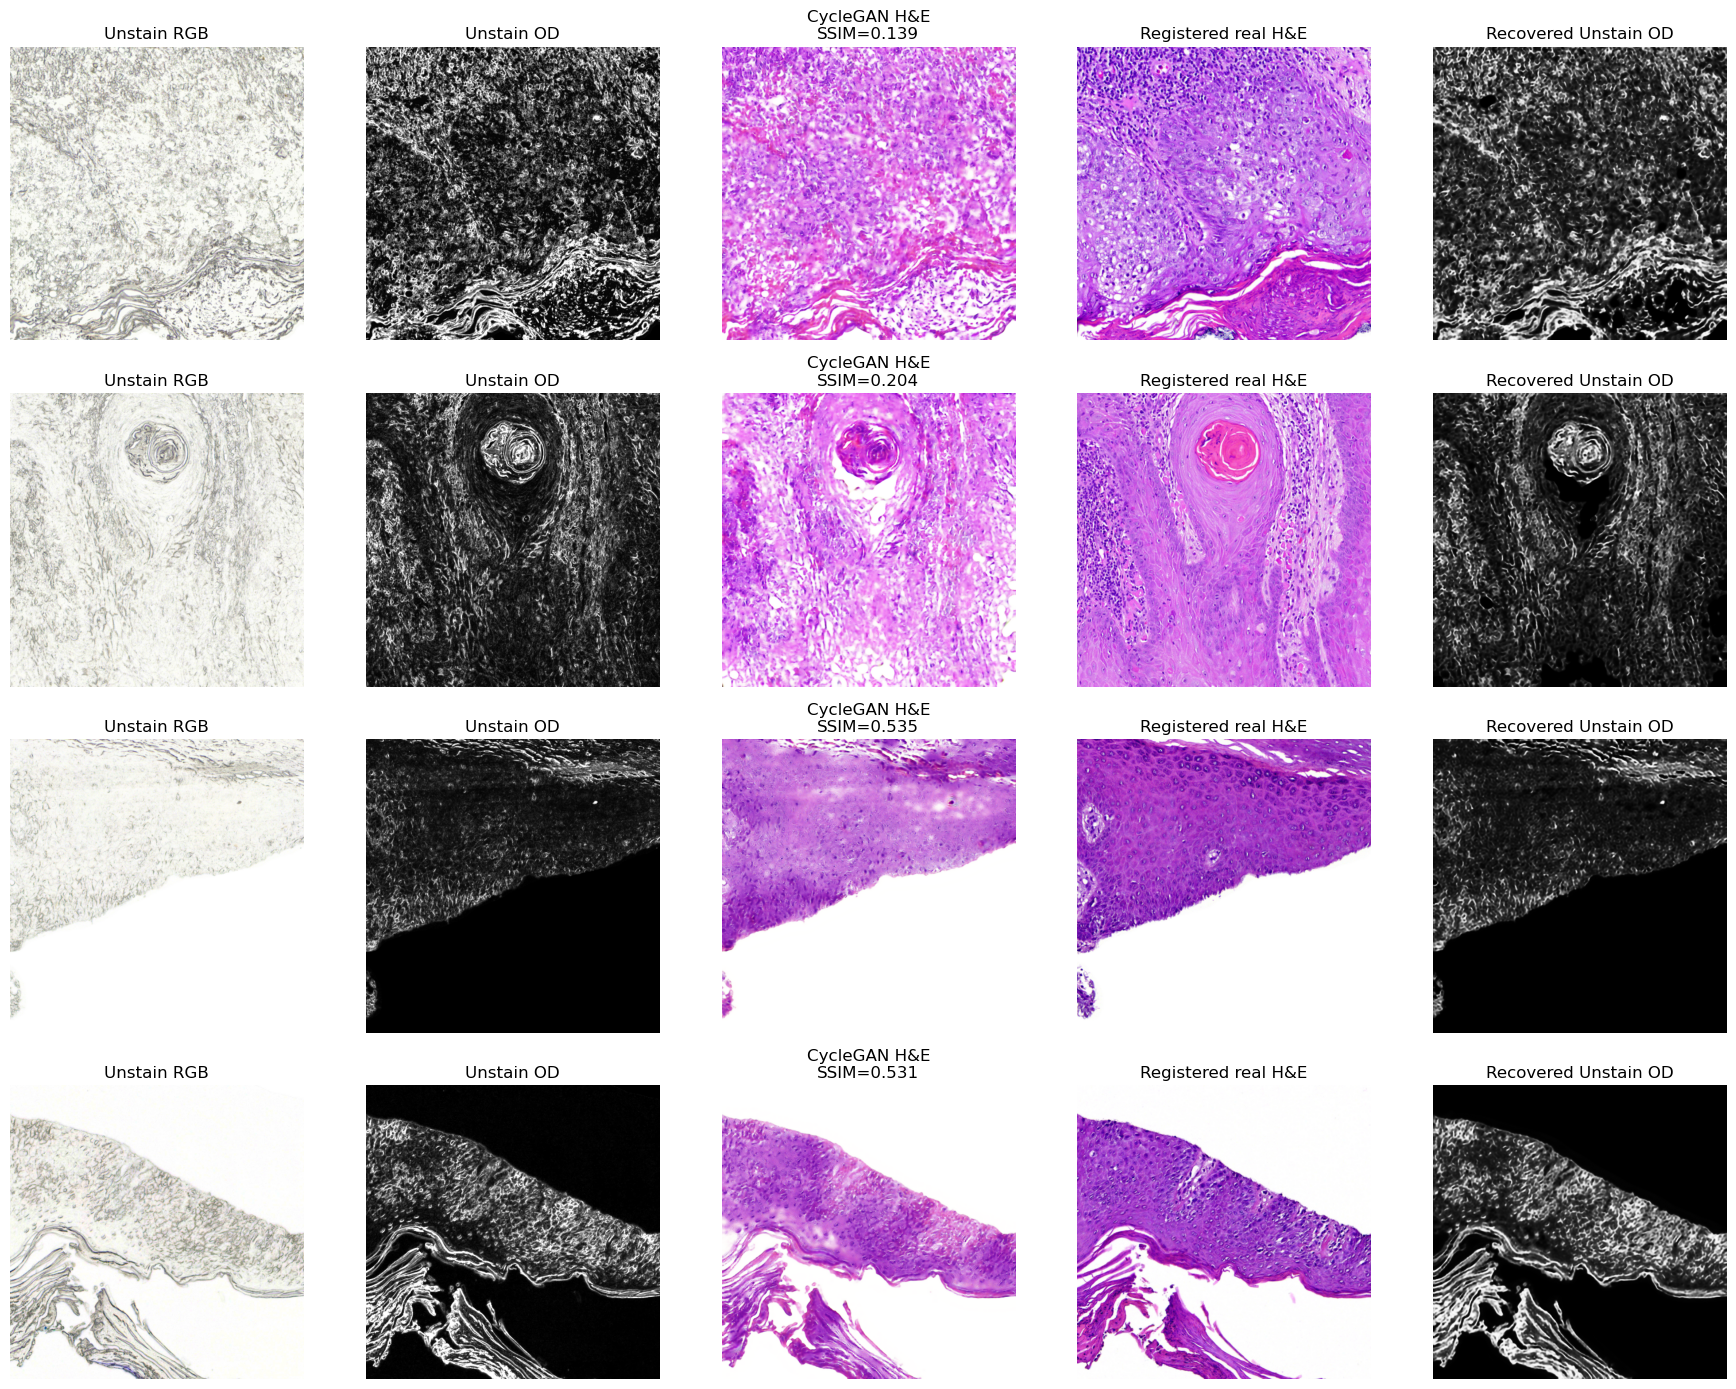

In [4]:
fig, axes = plt.subplots(len(patch_results), 5, figsize=(18, 3.5 * len(patch_results)), squeeze=False)
for row_index, (name, unstain_rgb, unstain_od, generated_rgb, real_hne, recovered_od, score) in enumerate(patch_results):
    prepared_unstain = prepare_physical_view(unstain_rgb, physical_params)
    panels = [
        (prepared_unstain, 'Unstain RGB'),
        ((unstain_od[0].numpy() + 1) / 2, 'Unstain OD'),
        (generated_rgb, f'CycleGAN H&E\nSSIM={score:.3f}'),
        (real_hne, 'Registered real H&E'),
        ((recovered_od.numpy() + 1) / 2, 'Recovered Unstain OD'),
    ]
    for column, (image, title) in enumerate(panels):
        grayscale = column in (1, 4)
        axes[row_index, column].imshow(
            image, cmap='gray' if grayscale else None,
            vmin=0 if grayscale else None, vmax=1 if grayscale else None,
        )
        axes[row_index, column].set_title(title)
        axes[row_index, column].axis('off')
    axes[row_index, 0].set_ylabel(name, fontsize=8)
fig.tight_layout()
PATCH_PREVIEW = OUTPUT_DIR / 'heldout_patch_test.png'
fig.savefig(PATCH_PREVIEW, dpi=150, bbox_inches='tight')
plt.show()

## 2. Whole-slide inference

512 px tile과 64 px overlap을 사용합니다. WSI 출력은 학습과 동일한 2.0 MPP pyramidal BigTIFF입니다.

In [5]:
wsi_info = infer_wsi(
    WSI_INPUT, WSI_OUTPUT, wsi_generator, identity_colorizer, metadata,
    tile_size=512, overlap=64, batch_size=4,
    fallback_mpp=0.5, minimum_tissue_fraction=0.002,
)
wsi_info

WSI inference at 2 MPP:   0%|          | 0/72 [00:00<?, ?it/s]

WSI inference at 2 MPP:   1%|▏         | 1/72 [00:00<00:10,  6.74it/s]

WSI inference at 2 MPP:   4%|▍         | 3/72 [00:00<00:06,  9.96it/s]

WSI inference at 2 MPP:   7%|▋         | 5/72 [00:00<00:06, 10.91it/s]

WSI inference at 2 MPP:  10%|▉         | 7/72 [00:00<00:05, 11.30it/s]

...

WSI inference at 2 MPP:  93%|█████████▎| 67/72 [00:09<00:00,  7.83it/s]

WSI inference at 2 MPP:  96%|█████████▌| 69/72 [00:09<00:00,  8.84it/s]

WSI inference at 2 MPP:  99%|█████████▊| 71/72 [00:09<00:00,  9.62it/s]

WSI inference at 2 MPP: 100%|██████████| 72/72 [00:09<00:00,  7.52it/s]

{'input': '../../data/HnE_n_UNStaining/Un-Stained-tiff/WC21-01958(A1-1).tiff',
 'output': '../../results/Unstain2HnE_paired_cyclegan_mpp20_v1/wsi_test/WC21-01958(A1-1)_CycleGAN_virtual_HnE_2mpp.tiff',
 'source_mpp': 0.5,
 'used_fallback_mpp': False,
 'target_mpp': 2.0,
 'saved_mpp': 2.0,
 'output_dimensions': (3732, 3617),
 'read_level': 1,
 'tiles': 72}

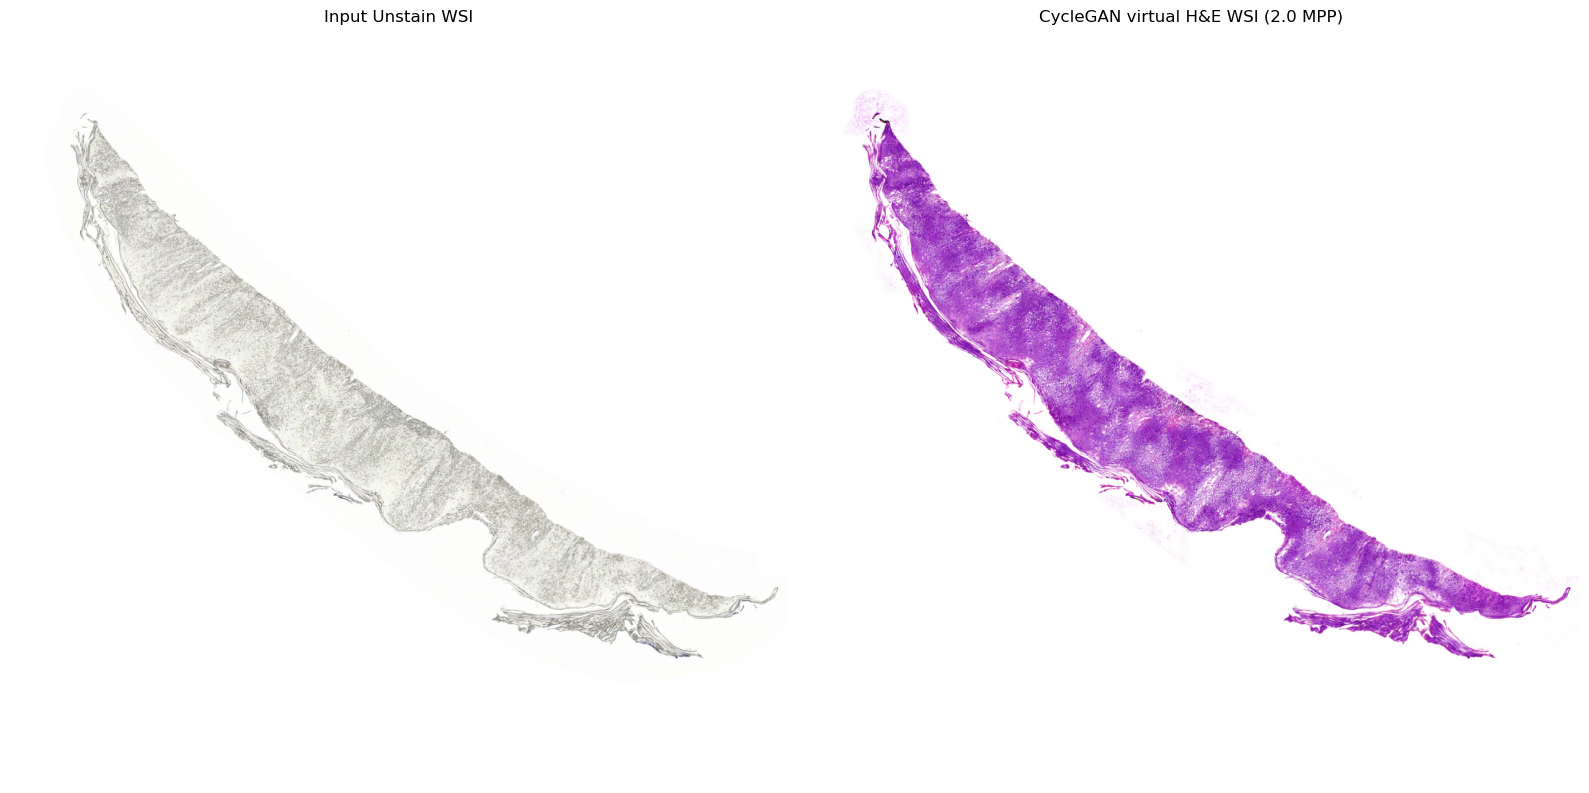

In [6]:
with openslide.OpenSlide(str(WSI_INPUT)) as input_slide, openslide.OpenSlide(str(WSI_OUTPUT)) as output_slide:
    input_thumb = input_slide.get_thumbnail((1400, 1400)).convert('RGB')
    output_thumb = output_slide.get_thumbnail((1400, 1400)).convert('RGB')

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
axes[0].imshow(input_thumb); axes[0].set_title('Input Unstain WSI')
axes[1].imshow(output_thumb); axes[1].set_title('CycleGAN virtual H&E WSI (2.0 MPP)')
for axis in axes: axis.axis('off')
fig.tight_layout()
WSI_PREVIEW = OUTPUT_DIR / f'{WSI_INPUT.stem}_wsi_preview.png'
fig.savefig(WSI_PREVIEW, dpi=150, bbox_inches='tight')
plt.show()

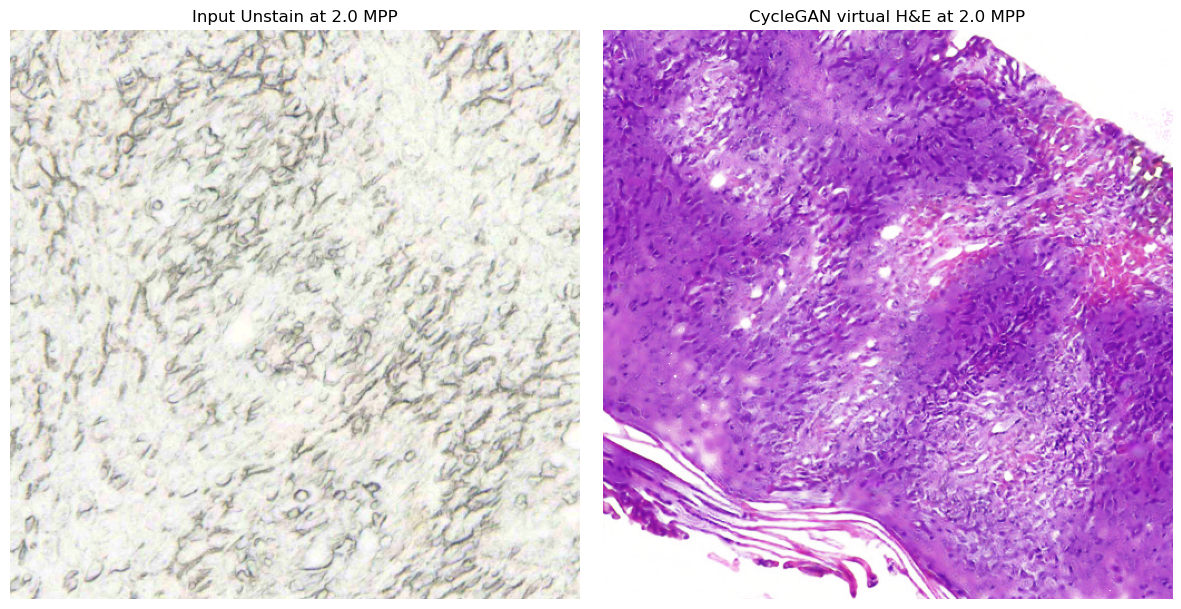

Saved:
../../results/Unstain2HnE_paired_cyclegan_mpp20_v1/wsi_test/WC21-01958(A1-1)_CycleGAN_virtual_HnE_2mpp.tiff
../../results/Unstain2HnE_paired_cyclegan_mpp20_v1/wsi_test/WC21-01958(A1-1)_wsi_preview.png
../../results/Unstain2HnE_paired_cyclegan_mpp20_v1/wsi_test/WC21-01958(A1-1)_wsi_zoom.png


In [7]:
with openslide.OpenSlide(str(WSI_OUTPUT)) as output_slide:
    thumb = output_slide.get_thumbnail((800, 800)).convert('RGB')
    thumb_np = np.asarray(thumb)
    tissue = np.min(thumb_np, axis=2) < 225
    yy, xx = np.where(tissue)
    center_out = (output_slide.dimensions[0] // 2, output_slide.dimensions[1] // 2) if len(xx) == 0 else (
        int(np.median(xx) * output_slide.dimensions[0] / thumb.width),
        int(np.median(yy) * output_slide.dimensions[1] / thumb.height),
    )
    x_out = max(0, min(output_slide.dimensions[0] - 512, center_out[0] - 256))
    y_out = max(0, min(output_slide.dimensions[1] - 512, center_out[1] - 256))
    generated_zoom = output_slide.read_region((x_out, y_out), 0, (512, 512)).convert('RGB')

scale = metadata['target_mpp'] / metadata['source_mpp']
with openslide.OpenSlide(str(WSI_INPUT)) as input_slide:
    level = input_slide.get_best_level_for_downsample(scale)
    input_zoom = input_slide.read_region(
        (round(x_out * scale), round(y_out * scale)), level, (512, 512)
    ).convert('RGB')

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(input_zoom); axes[0].set_title('Input Unstain at 2.0 MPP')
axes[1].imshow(generated_zoom); axes[1].set_title('CycleGAN virtual H&E at 2.0 MPP')
for axis in axes: axis.axis('off')
fig.tight_layout()
ZOOM_PREVIEW = OUTPUT_DIR / f'{WSI_INPUT.stem}_wsi_zoom.png'
fig.savefig(ZOOM_PREVIEW, dpi=150, bbox_inches='tight')
plt.show()
print('Saved:', WSI_OUTPUT, WSI_PREVIEW, ZOOM_PREVIEW, sep='\n')